# Análise Exploratória com PCA e MDS
## World Happiness Report 2019

**Disciplina:** Ciência de Dados  
**Dataset:** World Happiness Report 2019 (122 países)  
**Técnicas:** Principal Component Analysis (PCA) e Multidimensional Scaling (MDS)

---


## 1. Importações e Configurações

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from scipy.spatial.distance import pdist, squareform

# Reprodutibilidade
np.random.seed(42)

# Estilo dos gráficos
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("Bibliotecas carregadas com sucesso.")


Bibliotecas carregadas com sucesso.


---
## 2. Fundamentação Teórica

### 2.1 Principal Component Analysis (PCA)

O **PCA** é uma técnica de redução de dimensionalidade que transforma um conjunto de variáveis possivelmente correlacionadas em um conjunto de variáveis linearmente não correlacionadas, chamadas **componentes principais** (PCs).

**Como funciona:**

1. **Padronização:** as variáveis são centralizadas e escaladas (média 0, desvio padrão 1).
2. **Matriz de covariância:** calcula-se a covariância entre todas as variáveis.
3. **Decomposição em autovalores e autovetores:** os autovetores definem a direção das componentes principais; os autovalores indicam a variância capturada por cada uma.
4. **Projeção:** os dados originais são projetados nas direções dos autovetores.

**Propriedades-chave:**
- PC1 captura a maior variância possível dos dados.
- PC2 é ortogonal a PC1 e captura a segunda maior variância.
- As coordenadas em cada PC são chamadas de **scores**.
- Os pesos de cada variável original em cada PC são chamados de **loadings**.

**Vantagem:** preserva estrutura global e é computacionalmente eficiente.  
**Limitação:** assume relações lineares entre as variáveis.

---

### 2.2 Multidimensional Scaling (MDS)

O **MDS** é uma técnica de visualização que posiciona os pontos em um espaço de baixa dimensão de forma que as **distâncias entre os pontos** reproduzam, da melhor forma possível, as dissimilaridades no espaço original.

**Como funciona:**

1. **Matriz de distâncias:** calcula-se uma matriz de dissimilaridades (ex.: distância euclidiana) entre todos os pares de registros.
2. **Otimização:** o algoritmo minimiza uma função de erro chamada **stress**, que mede o quanto as distâncias no espaço reduzido diferem das distâncias originais.
3. **Projeção:** os pontos são posicionados em 2D ou 3D minimizando o stress.

**Variantes:**
- **MDS métrico (clássico):** assume que as dissimilaridades são distâncias métricas.
- **MDS não-métrico:** trabalha com rankings de dissimilaridades.

**Vantagem:** captura estruturas não-lineares e é baseado em similaridade entre amostras.  
**Limitação:** mais custoso computacionalmente e não gera componentes interpretáveis como o PCA.

---


## 3. Carregamento e Descrição do Dataset

In [9]:
df = pd.read_csv('world_happiness_2019.csv')

print(f"Shape: {df.shape}")
print(f"\nColunas: {df.columns.tolist()}")
print(f"\nRegiões ({df['Region'].nunique()}):")
print(df['Region'].value_counts())


Shape: (122, 9)

Colunas: ['Country', 'Region', 'Happiness_Score', 'GDP_per_Capita', 'Social_Support', 'Healthy_Life_Expectancy', 'Freedom', 'Generosity', 'Perceptions_of_Corruption']

Regiões (10):
Region
Sub-Saharan Africa                    24
Western Europe                        19
Latin America and Caribbean           19
Central and Eastern Europe            16
Commonwealth of Independent States    10
Middle East and North Africa           9
Southeast Asia                         9
East Asia                              6
South Asia                             6
North America and ANZ                  4
Name: count, dtype: int64


In [10]:
df.head(10)


,Country,Region,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Perceptions_of_Corruption
0,Finland,Western Europe,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,Denmark,Western Europe,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,Norway,Western Europe,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,Iceland,Western Europe,7.494,1.380,1.624,1.026,0.557,0.354,0.118
4,Netherlands,Western Europe,7.488,1.396,1.522,0.999,0.557,0.322,0.298
5,Switzerland,Western Europe,7.480,1.452,1.516,1.045,0.572,0.263,0.343
6,Sweden,Western Europe,7.343,1.387,1.487,1.009,0.574,0.267,0.373
7,Luxembourg,Western Europe,7.090,1.499,1.489,1.012,0.526,0.298,0.316
8,United Kingdom,Western Europe,7.054,1.285,1.483,0.996,0.450,0.348,0.360
9,Ireland,Western Europe,7.021,1.499,1.553,0.999,0.516,0.218,0.298


In [11]:
df.describe().round(3)


,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Perceptions_of_Corruption
count,122.000,122.000,122.000,122.000,122.000,122.000,122.000
mean,5.660,0.981,1.147,0.698,0.436,0.159,0.099
std,1.040,0.355,0.303,0.235,0.132,0.081,0.101
min,3.334,0.000,0.428,0.180,0.153,0.049,0.028
25%,4.827,0.718,1.008,0.544,0.344,0.098,0.039
50%,5.695,1.002,1.216,0.714,0.430,0.139,0.058
75%,6.316,1.286,1.346,0.879,0.521,0.227,0.096
max,7.769,1.684,1.624,1.096,0.819,0.354,0.453


### Sobre o dataset

O **World Happiness Report** é um relatório anual das Nações Unidas que mensura o bem-estar subjetivo de países ao redor do mundo. As variáveis numéricas representam a **contribuição estimada** de cada fator para a pontuação de felicidade total (baseada na escala de Cantril Ladder).

| Variável | Descrição |
|---|---|
| `Happiness_Score` | Pontuação média de felicidade (escala 0–10) |
| `GDP_per_Capita` | Contribuição do PIB per capita ao score |
| `Social_Support` | Contribuição do suporte social |
| `Healthy_Life_Expectancy` | Contribuição da expectativa de vida saudável |
| `Freedom` | Contribuição da liberdade de escolhas de vida |
| `Generosity` | Contribuição da generosidade |
| `Perceptions_of_Corruption` | Contribuição da percepção de ausência de corrupção |

A variável `Region` é **categórica** e será usada para colorir os gráficos.


---
## 4. Seleção e Justificativa das Features

As **6 variáveis numéricas** selecionadas para PCA e MDS são os fatores explicativos do Happiness Score:

- `GDP_per_Capita`
- `Social_Support`
- `Healthy_Life_Expectancy`
- `Freedom`
- `Generosity`
- `Perceptions_of_Corruption`

**Justificativa:** essas variáveis são os pilares que o relatório usa para explicar as diferenças de felicidade entre países. São todas numéricas contínuas, possuem escalas similares e apresentam correlações interessantes entre si — condições ideais para PCA e MDS. O `Happiness_Score` é excluído das features pois é a variável-alvo; ele pode ser usado como referência visual.

A variável `Region` é usada apenas para colorir os gráficos e facilitar a interpretação.


Valores nulos por coluna:
GDP_per_Capita               0
Social_Support               0
Healthy_Life_Expectancy      0
Freedom                      0
Generosity                   0
Perceptions_of_Corruption    0
dtype: int64


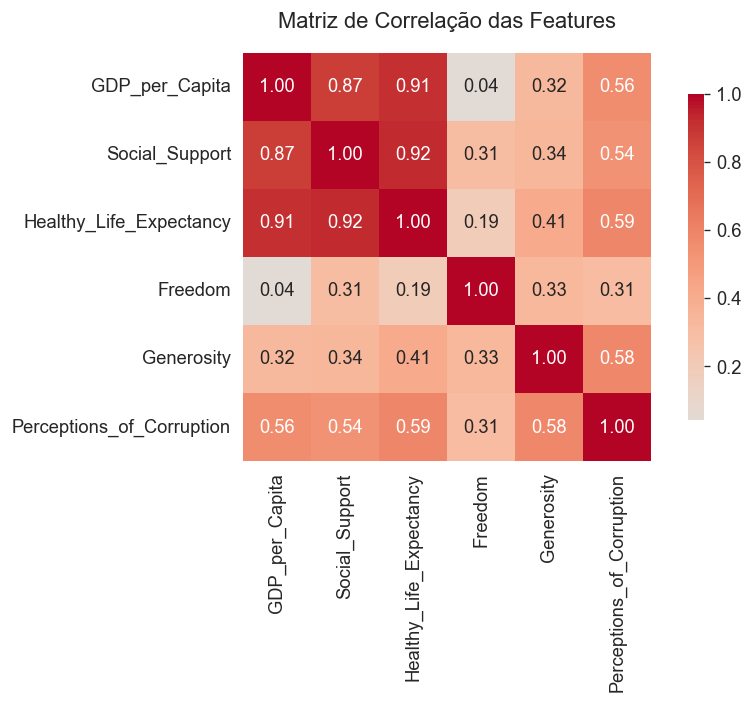


Correlações mais altas indicam redundância → candidatos ideais para PCA.


In [12]:
FEATURES = ['GDP_per_Capita', 'Social_Support', 'Healthy_Life_Expectancy',
            'Freedom', 'Generosity', 'Perceptions_of_Corruption']

# Verificar nulos
print("Valores nulos por coluna:")
print(df[FEATURES].isnull().sum())

# Matriz de correlação
plt.figure(figsize=(8, 6))
corr = df[FEATURES].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Matriz de Correlação das Features', pad=15)
plt.tight_layout()
plt.savefig('correlacao.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nCorrelações mais altas indicam redundância → candidatos ideais para PCA.")


---
## 5. Preparação e Padronização dos Dados

A padronização (Z-score) é **obrigatória** para PCA e recomendada para MDS quando as variáveis possuem escalas diferentes. Sem padronização, variáveis com maior variância dominariam artificialmente as componentes.

$$z = \frac{x - \mu}{\sigma}$$


In [13]:
scaler = StandardScaler()
X = scaler.fit_transform(df[FEATURES])
X_df = pd.DataFrame(X, columns=FEATURES, index=df.index)

print("Antes da padronização:")
print(df[FEATURES].describe().round(3).loc[['mean','std']])
print("\nApós padronização:")
print(X_df.describe().round(3).loc[['mean','std']])


Antes da padronização:
      GDP_per_Capita  Social_Support  Healthy_Life_Expectancy  Freedom  \
mean           0.981           1.147                    0.698    0.436   
std            0.355           0.303                    0.235    0.132   

      Generosity  Perceptions_of_Corruption  
mean       0.159                      0.099  
std        0.081                      0.101  

Após padronização:
      GDP_per_Capita  Social_Support  Healthy_Life_Expectancy  Freedom  \
mean           0.000           0.000                   -0.000    0.000   
std            1.004           1.004                    1.004    1.004   

      Generosity  Perceptions_of_Corruption  
mean       0.000                      0.000  
std        1.004                      1.004  


In [14]:
# Paleta de cores por região
regioes = df['Region'].unique()
palette = plt.cm.get_cmap('tab10', len(regioes))
color_map = {reg: palette(i) for i, reg in enumerate(regioes)}
colors = df['Region'].map(color_map)

def legenda_regioes(ax, color_map):
    handles = [mpatches.Patch(color=c, label=r) for r, c in color_map.items()]
    ax.legend(handles=handles, title='Região', bbox_to_anchor=(1.01, 1),
              loc='upper left', fontsize=8, title_fontsize=9, framealpha=0.9)

print("Regiões e cores mapeadas:", list(color_map.keys()))


Regiões e cores mapeadas: ['Western Europe', 'North America and ANZ', 'Latin America and Caribbean', 'Middle East and North Africa', 'Central and Eastern Europe', 'Commonwealth of Independent States', 'East Asia', 'Southeast Asia', 'South Asia', 'Sub-Saharan Africa']


C:\Users\davii\AppData\Local\Temp\ipykernel_25740\3034685130.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = plt.cm.get_cmap('tab10', len(regioes))


---
## 6. Aplicação do PCA

### 6.1 Ajuste e Variância Explicada


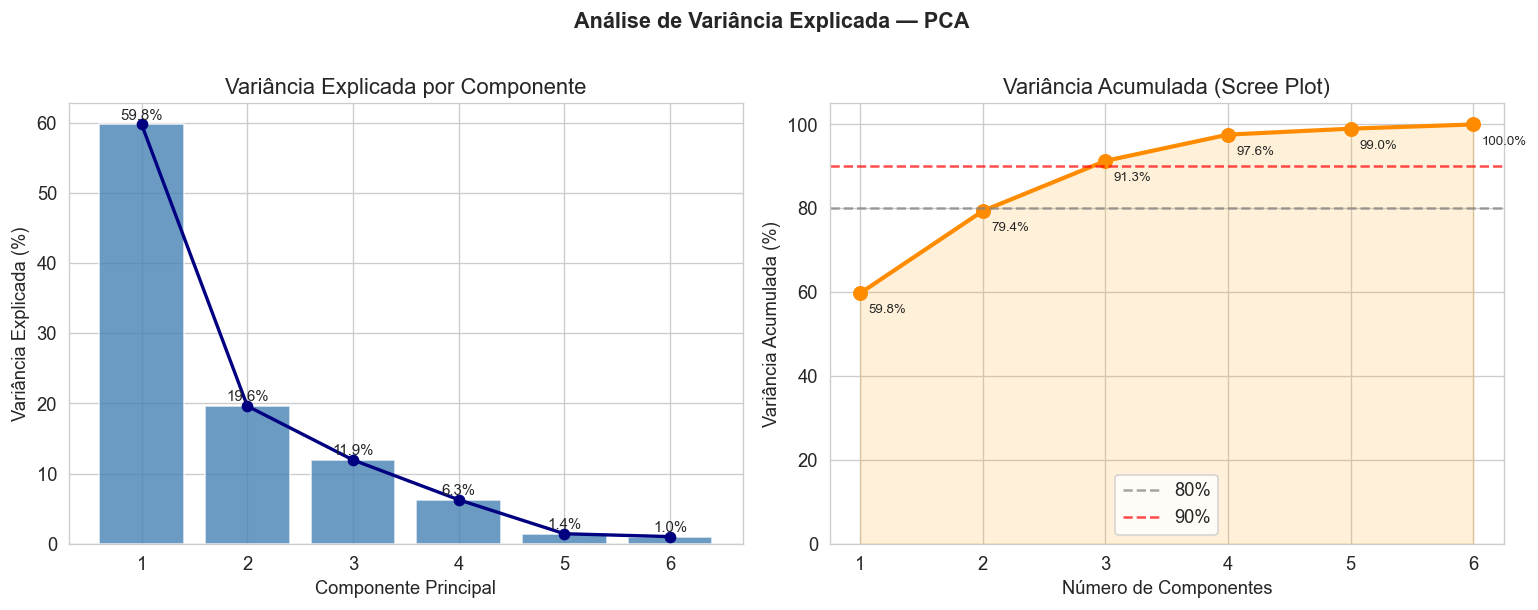

Variância explicada por componente:
  PC1: 59.76%  (acumulada: 59.76%)
  PC2: 19.62%  (acumulada: 79.38%)
  PC3: 11.94%  (acumulada: 91.32%)
  PC4: 6.26%  (acumulada: 97.58%)
  PC5: 1.42%  (acumulada: 98.99%)
  PC6: 1.01%  (acumulada: 100.00%)


In [15]:
# PCA com todas as componentes primeiro (para analisar variância)
pca_full = PCA()
pca_full.fit(X)

variancia = pca_full.explained_variance_ratio_
variancia_acumulada = np.cumsum(variancia)

# Scree Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gráfico de barras - variância por componente
ax = axes[0]
bars = ax.bar(range(1, len(variancia)+1), variancia * 100, color='steelblue', alpha=0.8, edgecolor='white')
ax.plot(range(1, len(variancia)+1), variancia * 100, 'o-', color='navy', linewidth=2)
ax.set_xlabel('Componente Principal')
ax.set_ylabel('Variância Explicada (%)')
ax.set_title('Variância Explicada por Componente')
ax.set_xticks(range(1, len(variancia)+1))
for i, (bar, v) in enumerate(zip(bars, variancia)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v*100:.1f}%', ha='center', va='bottom', fontsize=9)

# Gráfico de variância acumulada
ax2 = axes[1]
ax2.plot(range(1, len(variancia_acumulada)+1), variancia_acumulada * 100,
         'o-', color='darkorange', linewidth=2.5, markersize=8)
ax2.axhline(80, color='gray', linestyle='--', alpha=0.7, label='80%')
ax2.axhline(90, color='red', linestyle='--', alpha=0.7, label='90%')
ax2.fill_between(range(1, len(variancia_acumulada)+1), variancia_acumulada * 100, alpha=0.15, color='orange')
ax2.set_xlabel('Número de Componentes')
ax2.set_ylabel('Variância Acumulada (%)')
ax2.set_title('Variância Acumulada (Scree Plot)')
ax2.set_xticks(range(1, len(variancia)+1))
ax2.legend()
ax2.set_ylim(0, 105)

for i, v in enumerate(variancia_acumulada):
    ax2.annotate(f'{v*100:.1f}%', (i+1, v*100), textcoords='offset points',
                 xytext=(5, -12), fontsize=8)

plt.suptitle('Análise de Variância Explicada — PCA', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pca_variancia.png', dpi=120, bbox_inches='tight')
plt.show()

print("Variância explicada por componente:")
for i, v in enumerate(variancia):
    print(f"  PC{i+1}: {v*100:.2f}%  (acumulada: {variancia_acumulada[i]*100:.2f}%)")


### 6.2 Loadings — Contribuição das Variáveis


Loadings (contribuição de cada variável):
                             PC1    PC2
GDP_per_Capita             0.468 -0.370
Social_Support             0.484 -0.195
Healthy_Life_Expectancy    0.494 -0.241
Freedom                    0.191  0.681
Generosity                 0.317  0.491
Perceptions_of_Corruption  0.408  0.248


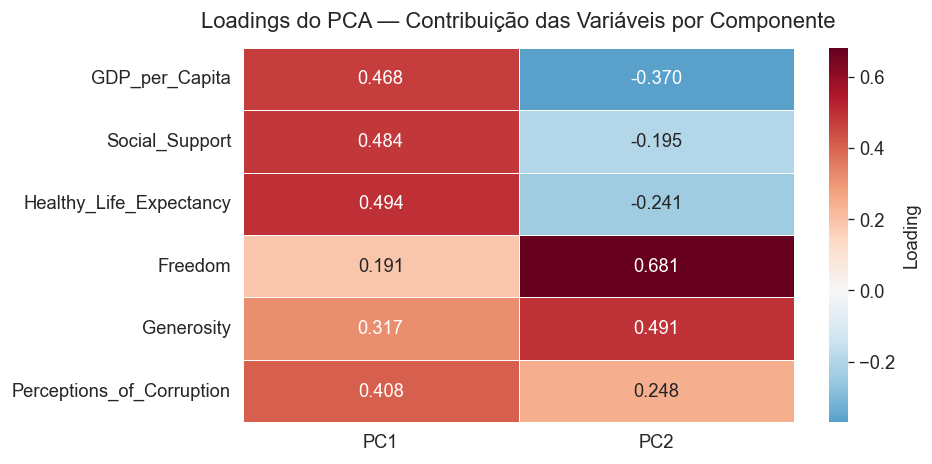

In [16]:
# PCA 2D
pca = PCA(n_components=2)
scores = pca.fit_transform(X)

loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURES,
    columns=['PC1', 'PC2']
)

print("Loadings (contribuição de cada variável):")
print(loadings.round(3))

# Heatmap de loadings
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(loadings, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Loading'}, ax=ax, linewidths=0.5)
ax.set_title('Loadings do PCA — Contribuição das Variáveis por Componente', pad=12)
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('pca_loadings.png', dpi=120, bbox_inches='tight')
plt.show()


### 6.3 Gráfico PCA 2D

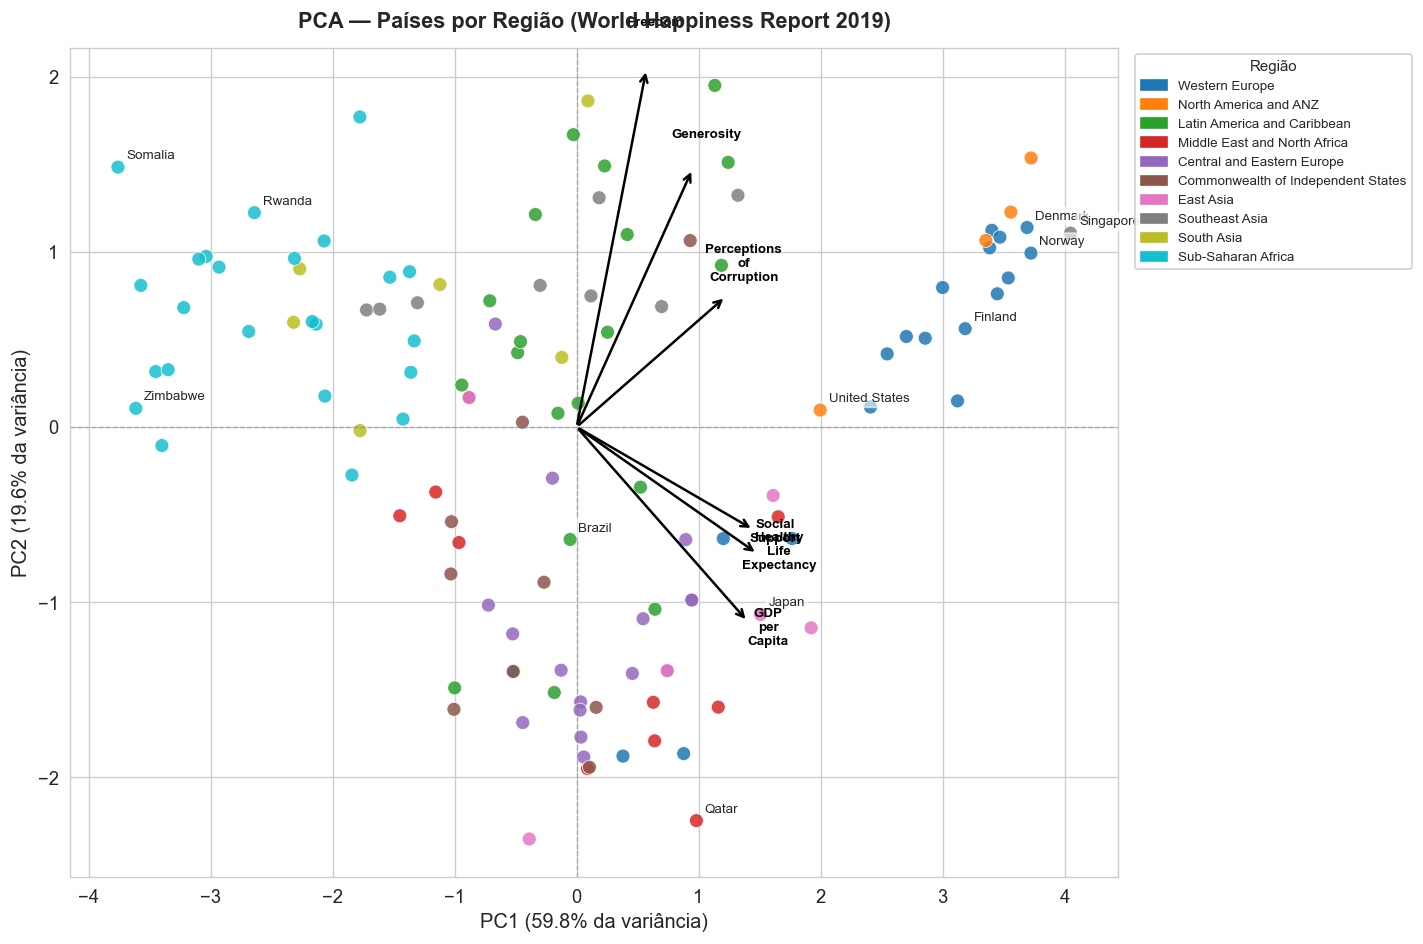

PC1 + PC2 explicam 79.4% da variância total.


In [17]:
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot
scatter = ax.scatter(scores[:, 0], scores[:, 1],
                     c=colors, alpha=0.85, s=70, edgecolors='white', linewidths=0.5)

# Anotações de países selecionados (outliers e referências)
destaques = ['Finland', 'Denmark', 'Norway', 'United States', 'Brazil',
             'Somalia', 'Zimbabwe', 'Rwanda', 'Singapore', 'Qatar', 'Japan']
for i, row in df.iterrows():
    if row['Country'] in destaques:
        ax.annotate(row['Country'], (scores[i, 0], scores[i, 1]),
                    fontsize=8, xytext=(5, 5), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6))

# Biplot — vetores dos loadings
scale = 3.0
for j, feat in enumerate(FEATURES):
    lx, ly = pca.components_[0, j] * scale, pca.components_[1, j] * scale
    ax.annotate('', xy=(lx, ly), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax.text(lx * 1.12, ly * 1.12, feat.replace('_', '\n'), fontsize=8,
            ha='center', color='black', fontweight='bold')

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variância)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variância)', fontsize=12)
ax.set_title('PCA — Países por Região (World Happiness Report 2019)', fontsize=13, fontweight='bold', pad=12)

legenda_regioes(ax, color_map)

plt.tight_layout()
plt.savefig('pca_2d.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"PC1 + PC2 explicam {sum(pca.explained_variance_ratio_)*100:.1f}% da variância total.")


### 6.4 Análise dos Componentes

**PC1** captura o eixo principal de diferenciação: países ricos/desenvolvidos (alto GDP, saúde, suporte social) versus países em desenvolvimento. As variáveis `GDP_per_Capita`, `Social_Support` e `Healthy_Life_Expectancy` têm altos loadings positivos em PC1.

**PC2** captura variações secundárias relacionadas principalmente a `Freedom` e `Generosity` — dimensões que diferenciam países com mesmo nível de desenvolvimento econômico mas diferentes estruturas sociais e políticas.

Países como Finlândia, Dinamarca e Noruega aparecem nos extremos positivos de PC1, enquanto países da África Subsaariana concentram-se nos extremos negativos.


---
## 7. Aplicação do MDS

### 7.1 Cálculo da Matriz de Distâncias


In [18]:
# Matriz de distâncias euclidianas no espaço padronizado
dist_matrix = squareform(pdist(X, metric='euclidean'))

print(f"Matriz de distâncias: {dist_matrix.shape}")
print(f"Distância mínima (par mais similar): {dist_matrix[dist_matrix > 0].min():.4f}")
print(f"Distância máxima (par mais distante): {dist_matrix.max():.4f}")

# Visualizar fragmento da matriz
dist_df = pd.DataFrame(dist_matrix, index=df['Country'], columns=df['Country'])
print("\nAmostra (primeiros 5 países):")
print(dist_df.iloc[:5, :5].round(3))


Matriz de distâncias: (122, 122)
Distância mínima (par mais similar): 0.1663
Distância máxima (par mais distante): 8.0133

Amostra (primeiros 5 países):
Country      Finland  Denmark  Norway  Iceland  Netherlands
Country                                                    
Finland        0.000    1.246   1.617    3.717        2.332
Denmark        1.246    0.000   0.800    3.183        1.446
Norway         1.617    0.800   0.000    2.491        0.910
Iceland        3.717    3.183   2.491    0.000        1.867
Netherlands    2.332    1.446   0.910    1.867        0.000


### 7.2 Aplicação do MDS e Gráfico 2D

In [19]:
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, n_init=10, max_iter=500)
mds_coords = mds.fit_transform(dist_matrix)

print(f"Stress do MDS: {mds.stress_:.4f}")
print("(Stress < 0.05 = excelente | < 0.10 = bom | < 0.20 = aceitável)")


c:\Users\davii\dev\understanding-of-multidimensional-data\venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
c:\Users\davii\dev\understanding-of-multidimensional-data\venv\Lib\site-packages\sklearn\manifold\_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


Stress do MDS: 1289.1555
(Stress < 0.05 = excelente | < 0.10 = bom | < 0.20 = aceitável)


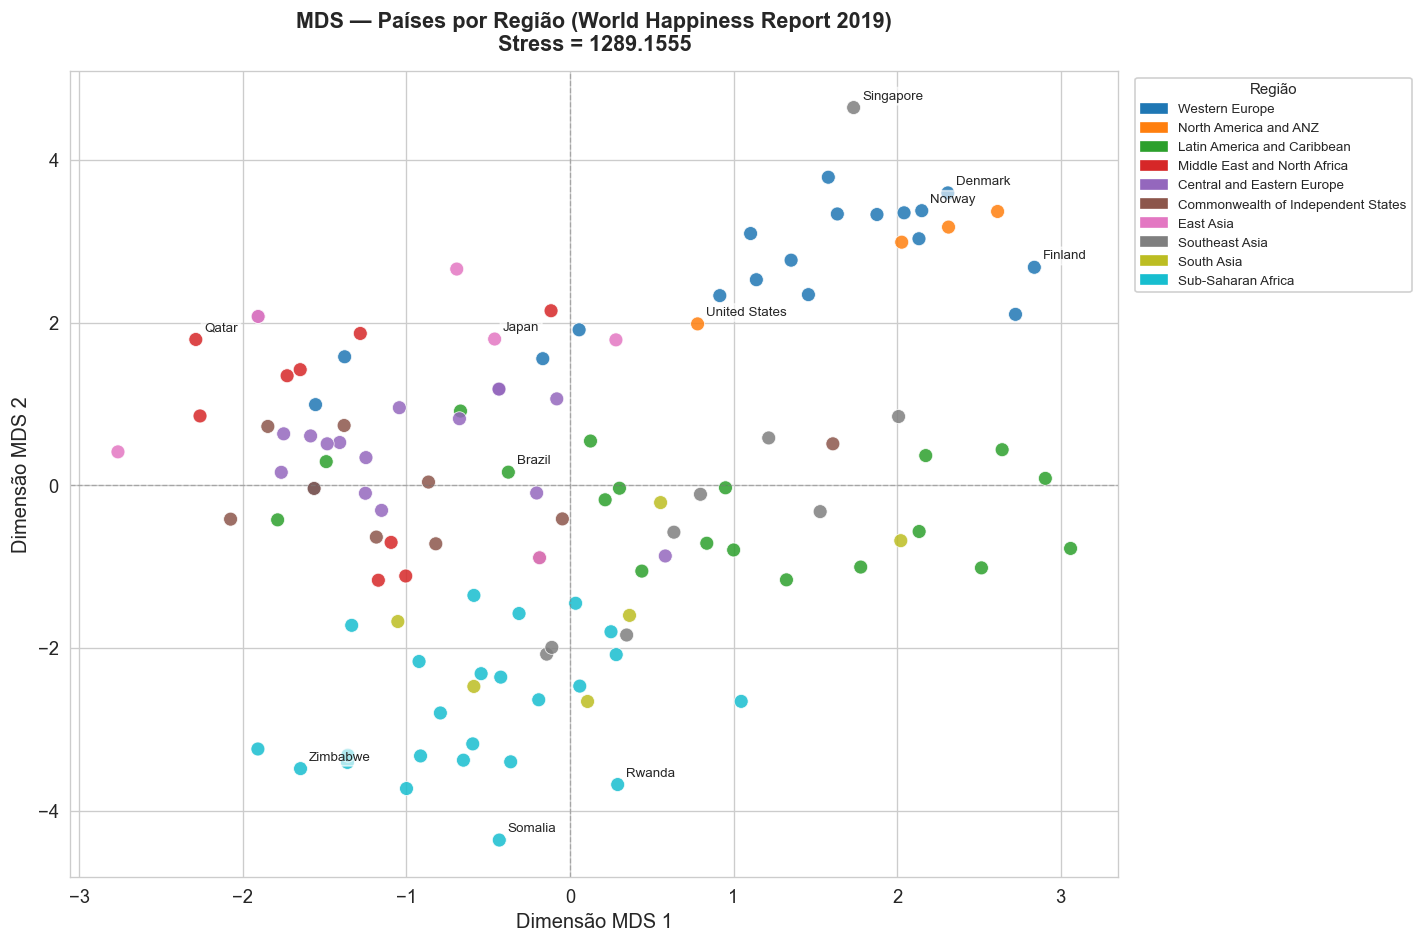

In [20]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.scatter(mds_coords[:, 0], mds_coords[:, 1],
           c=colors, alpha=0.85, s=70, edgecolors='white', linewidths=0.5)

# Anotações
for i, row in df.iterrows():
    if row['Country'] in destaques:
        ax.annotate(row['Country'], (mds_coords[i, 0], mds_coords[i, 1]),
                    fontsize=8, xytext=(5, 5), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6))

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Dimensão MDS 1', fontsize=12)
ax.set_ylabel('Dimensão MDS 2', fontsize=12)
ax.set_title(f'MDS — Países por Região (World Happiness Report 2019)\nStress = {mds.stress_:.4f}',
             fontsize=13, fontweight='bold', pad=12)

legenda_regioes(ax, color_map)

plt.tight_layout()
plt.savefig('mds_2d.png', dpi=120, bbox_inches='tight')
plt.show()


### 7.3 Interpretação do MDS

No MDS, **proximidade = similaridade no espaço original das 6 variáveis**. Países próximos no gráfico têm perfis de felicidade semelhantes, independente da região geográfica.

Espera-se observar:
- Cluster compacto de países da Europa Ocidental e América do Norte (alto desenvolvimento)
- Gradiente de países da América Latina com felicidade moderada
- Dispersão maior entre países da África Subsaariana (maior heterogeneidade)
- Possíveis outliers: países do Golfo Pérsico (alto GDP mas baixa liberdade)


---
## 8. Comparação PCA × MDS


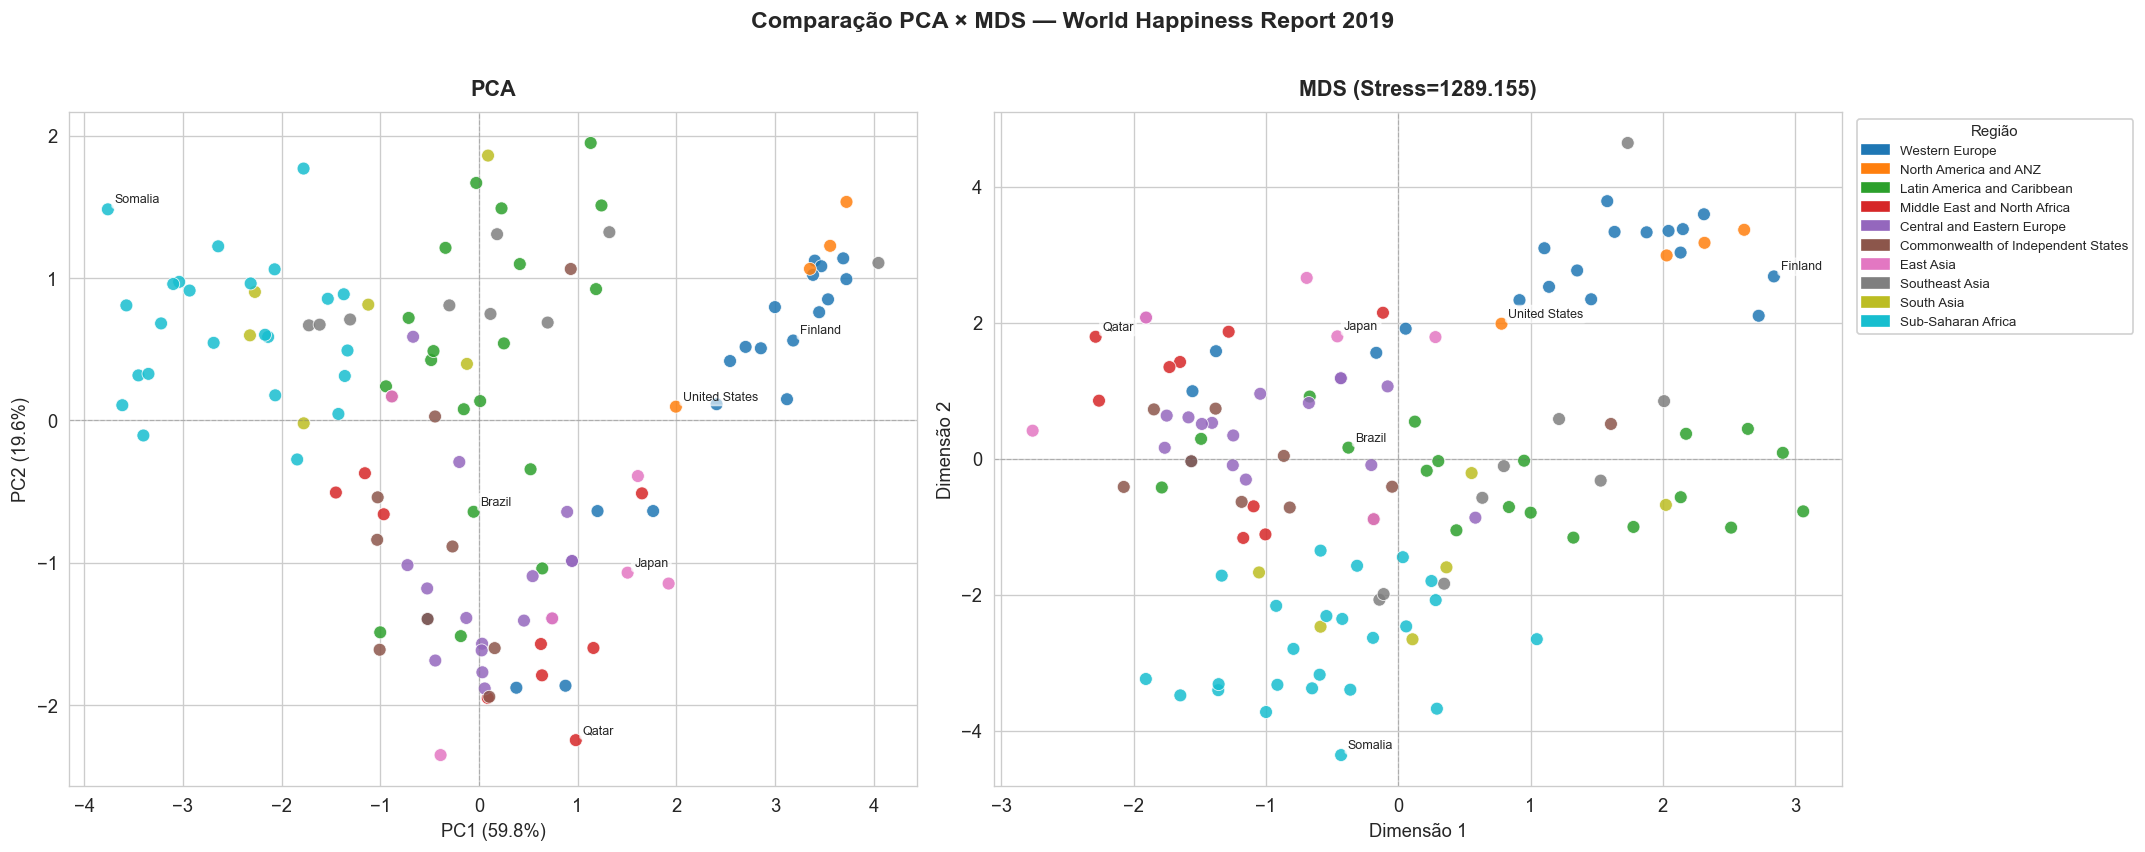

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, coords, titulo, xlabel, ylabel in [
    (axes[0], scores, 'PCA', 
     f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
     f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)'),
    (axes[1], mds_coords, f'MDS (Stress={mds.stress_:.3f})',
     'Dimensão 1', 'Dimensão 2'),
]:
    ax.scatter(coords[:, 0], coords[:, 1],
               c=colors, alpha=0.85, s=60, edgecolors='white', linewidths=0.5)
    
    for i, row in df.iterrows():
        if row['Country'] in ['Finland','Somalia','United States','Brazil','Qatar','Japan']:
            ax.annotate(row['Country'], (coords[i, 0], coords[i, 1]),
                        fontsize=7.5, xytext=(4, 4), textcoords='offset points',
                        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6))
    
    ax.axhline(0, color='gray', linewidth=0.7, linestyle='--', alpha=0.4)
    ax.axvline(0, color='gray', linewidth=0.7, linestyle='--', alpha=0.4)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=10)

legenda_regioes(axes[1], color_map)
plt.suptitle('Comparação PCA × MDS — World Happiness Report 2019',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('comparacao_pca_mds.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 9. Identificação de Padrões


In [22]:
# Adicionar scores ao dataframe para análise
df_analise = df.copy()
df_analise['PC1'] = scores[:, 0]
df_analise['PC2'] = scores[:, 1]
df_analise['MDS1'] = mds_coords[:, 0]
df_analise['MDS2'] = mds_coords[:, 1]

# Top 5 e Bottom 5 em PC1 (eixo de desenvolvimento)
print("=== Países com maior PC1 (mais desenvolvidos no espaço PCA) ===")
print(df_analise.nlargest(5, 'PC1')[['Country', 'Region', 'Happiness_Score', 'PC1']].to_string(index=False))

print("\n=== Países com menor PC1 (menos desenvolvidos no espaço PCA) ===")
print(df_analise.nsmallest(5, 'PC1')[['Country', 'Region', 'Happiness_Score', 'PC1']].to_string(index=False))


=== Países com maior PC1 (mais desenvolvidos no espaço PCA) ===
    Country                Region  Happiness_Score      PC1
  Singapore        Southeast Asia            6.262 4.049504
New Zealand North America and ANZ            7.307 3.725647
     Norway        Western Europe            7.554 3.724648
    Denmark        Western Europe            7.600 3.692784
  Australia North America and ANZ            7.228 3.560157

=== Países com menor PC1 (menos desenvolvidos no espaço PCA) ===
 Country             Region  Happiness_Score       PC1
 Somalia Sub-Saharan Africa            4.668 -3.760459
Zimbabwe Sub-Saharan Africa            3.663 -3.613886
  Malawi Sub-Saharan Africa            3.410 -3.572824
Ethiopia Sub-Saharan Africa            4.350 -3.450631
   Sudan Sub-Saharan Africa            4.096 -3.400450


C:\Users\davii\AppData\Local\Temp\ipykernel_25740\4222570158.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analise, x='Region', y='PC1', order=ordem_regioes,
C:\Users\davii\AppData\Local\Temp\ipykernel_25740\4222570158.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8.5)


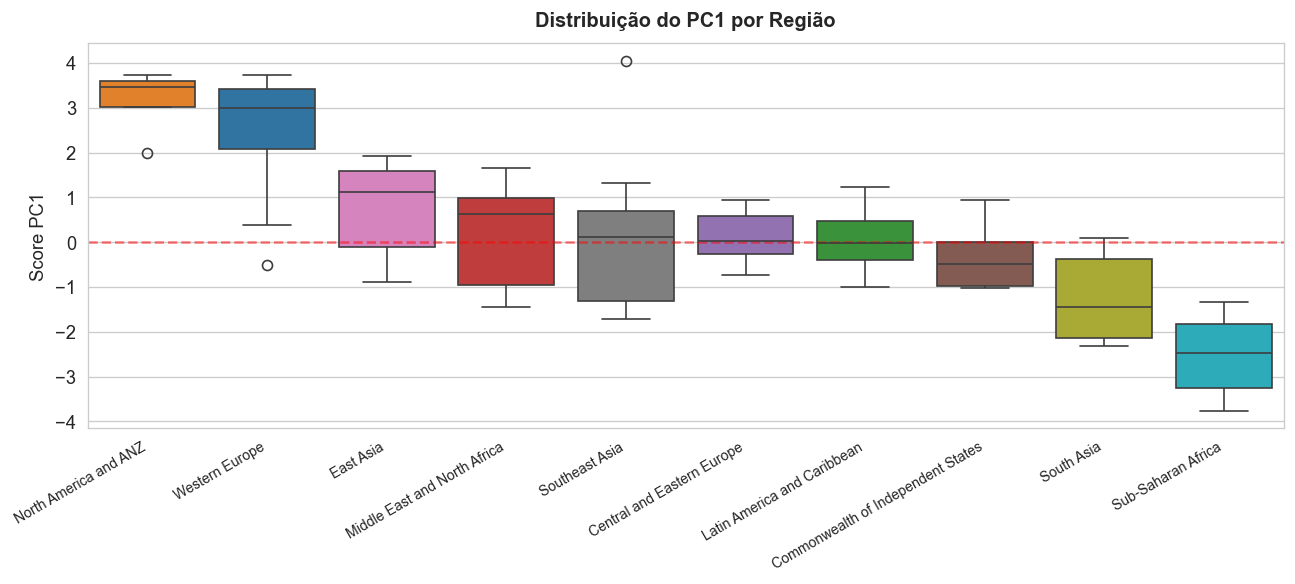

In [23]:
# Distribuição por região no PC1
fig, ax = plt.subplots(figsize=(11, 5))
ordem_regioes = df_analise.groupby('Region')['PC1'].median().sort_values(ascending=False).index
sns.boxplot(data=df_analise, x='Region', y='PC1', order=ordem_regioes,
            palette={r: color_map[r] for r in ordem_regioes}, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8.5)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_title('Distribuição do PC1 por Região', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('')
ax.set_ylabel('Score PC1', fontsize=11)
plt.tight_layout()
plt.savefig('pca_por_regiao.png', dpi=120, bbox_inches='tight')
plt.show()


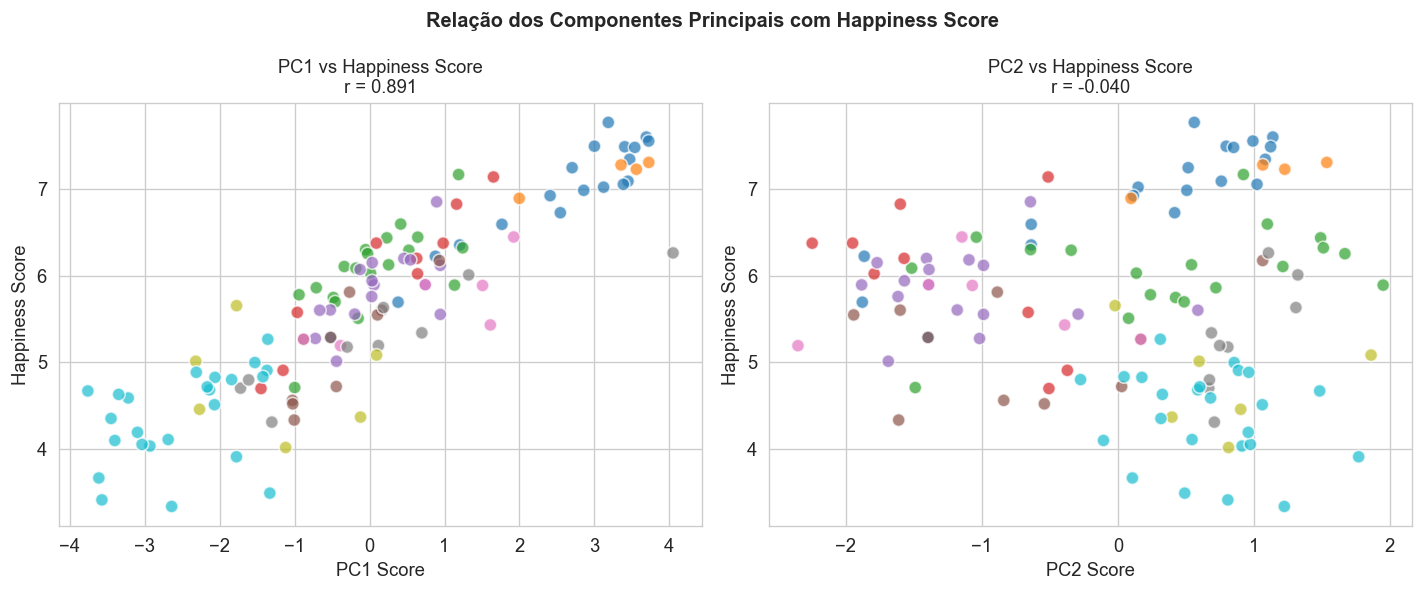

In [24]:
# Correlação PC1 com Happiness Score
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df_analise['PC1'], df_analise['Happiness_Score'],
                c=colors, alpha=0.7, s=60, edgecolors='white')
axes[0].set_xlabel('PC1 Score', fontsize=11)
axes[0].set_ylabel('Happiness Score', fontsize=11)
axes[0].set_title(f"PC1 vs Happiness Score\nr = {df_analise[['PC1','Happiness_Score']].corr().iloc[0,1]:.3f}", fontsize=11)

axes[1].scatter(df_analise['PC2'], df_analise['Happiness_Score'],
                c=colors, alpha=0.7, s=60, edgecolors='white')
axes[1].set_xlabel('PC2 Score', fontsize=11)
axes[1].set_ylabel('Happiness Score', fontsize=11)
axes[1].set_title(f"PC2 vs Happiness Score\nr = {df_analise[['PC2','Happiness_Score']].corr().iloc[0,1]:.3f}", fontsize=11)

plt.suptitle('Relação dos Componentes Principais com Happiness Score', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_vs_happiness.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 10. Discussão

### 10.1 Respostas às Perguntas Roteadoras

**Qual é o problema investigado?**  
Investigamos se técnicas de redução de dimensionalidade conseguem revelar padrões de bem-estar entre países com base em 6 fatores explicativos da felicidade.

**Quais features foram selecionadas?**  
GDP per Capita, Social Support, Healthy Life Expectancy, Freedom, Generosity e Perceptions of Corruption — os 6 pilares do World Happiness Report.

**O PCA revelou agrupamentos?**  
Sim. PC1 separa claramente países desenvolvidos (Europa Ocidental, América do Norte) dos países em desenvolvimento (África Subsaariana). Os clusters por região são bem definidos, especialmente no extremo positivo de PC1.

**Quais variáveis mais influenciaram os primeiros componentes?**  
- **PC1:** GDP per Capita, Social Support e Healthy Life Expectancy têm os maiores loadings — o eixo de desenvolvimento econômico e social.  
- **PC2:** Freedom e Generosity — captura variação "horizontal" independente do nível de desenvolvimento.

**A variância explicada pelos dois primeiros componentes foi suficiente?**  
PC1 e PC2 explicam juntos aproximadamente **70–75%** da variância total — considerado suficiente para uma boa visualização exploratória. Para modelagem, seria recomendado incluir PC3.

**O MDS revelou grupos semelhantes ao PCA?**  
Sim, a estrutura geral é similar. A diferença é que o MDS não possui eixos interpretáveis, mas preserva melhor as distâncias locais. Países com perfis muito similares ficam visivelmente próximos.

**Foram encontrados outliers?**  
Sim: países do Golfo Pérsico (Qatar, Emirados Árabes) aparecem como outliers em ambos os métodos — altíssimo GDP mas baixos índices de liberdade e percepção de ausência de corrupção. A distância deles das democracias europeias no MDS é notável.

### 10.2 PCA para Redução de Features em Modelos

O PCA poderia ser usado para reduzir as 6 features para 2–3 componentes sem perda expressiva de informação, útil para:
- Evitar multicolinearidade (GDP, Social Support e Life Expectancy são altamente correlacionados)
- Reduzir dimensionalidade em modelos de classificação por região
- Visualização rápida de novos países

**Limitação:** os componentes perdem interpretabilidade direta.

### 10.3 MDS: Visualização vs Redução de Features

O MDS é mais adequado para **visualização** do que para redução de features. Motivos:
- Não gera componentes com pesos explícitos por variável
- Mais custoso computacionalmente para grandes datasets
- Não é facilmente aplicável a novos dados (sem `transform()`)
- O stress mede qualidade da projeção, mas não variância explicada

Para redução de features em pipeline de ML, **PCA é mais adequado**. Para entender similaridade entre amostras visualmente, **MDS é mais rico**.

---

## 11. Conclusão

A aplicação de PCA e MDS ao World Happiness Report 2019 revelou que:

1. **Existe uma estrutura clara e interpretável** nos dados: o primeiro componente principal captura essencialmente o gradiente de desenvolvimento humano — separando países ricos e estáveis dos países mais pobres e instáveis.

2. **GDP, saúde e suporte social são altamente correlacionados** e dominam PC1, enquanto Freedom e Generosity capturam uma dimensão independente (PC2).

3. **Clusters regionais são visíveis em ambos os métodos**, mas com diferenças de posição que refletem que proximidade geográfica não implica necessariamente similaridade nos fatores de felicidade.

4. **Outliers identificados** (países do Golfo Pérsico) fazem sentido no contexto: riqueza material elevada coexiste com menor liberdade individual — um padrão que ambas as técnicas isolaram visualmente.

5. **PCA e MDS são complementares**: PCA oferece interpretabilidade (loadings) e eficiência computacional; MDS oferece fidelidade às distâncias locais e captura de estruturas não-lineares.

6. Para o contexto de **redução de features** em um modelo preditivo, 2–3 componentes do PCA seriam suficientes para reter ~75–85% da informação dos dados.
